In [1]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipy.ndimage.filters import gaussian_filter1d
from lifted_embedding_estimation_with_truth_value import name2lstr

In [2]:
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dm', 'up-dm']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = .1

In [3]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [24]:
def plot_train_lines(lines, lstr=None):
    rec = filter_lines(lines=lines, key_str="learn")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)
    
    if lstr:
        df = df[df.lstr == lstr]
        
    if len(df) > 100000:
        df = df.sample(n=100000)

    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(20, 6))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')
    keys = ['pos_tv', 'neg_tv', 'lifted_tv']
    for label in keys:
        if label in df.columns:
            ax1.plot(df['id'], df[label], alpha=0.5, label=label)
            # ax1.scatter(df['id'], df[label], s=1, label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    ax1.set_ylim([0, 1])


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')
    keys = ['loss', 'pos_nll', 'neg_nll', 'lifted_nll', 'contrastive_nll']
    for label in keys:
        if label in df:
            ax2.plot(df['id'], df[label], alpha=0.5, label=label)
            # ax2.scatter(df['id'], df[label], s=1, label=label)
            
    ax2.legend()
    # ax2.set_yscale('log')
    
    keys = ['pos_score', 'neg_score']
    for label in keys:
        if label in df:
            ax3.plot(df['id'], df[label], alpha=0.5, label=label)
            # ax3.scatter(df['id'], df[label], s=1, label=label)
            
    ax3.legend()
    # ax3.set_ylim([0, 1])

    ax3.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation(scope=['train', 'validate', 'test']):
    all_rec = filter_lines(lines=lines, key_str="evaluate")

    
    for k in queries:        
        if not any(k in rec for rec in all_rec): continue
        fig, axes = plt.subplots(ncols=len(scope), figsize=(3 * len(scope) + 1, 3))
        
        if len(scope) == 1:
            axes = [axes]

        for ax, desc in zip(axes, scope):
            rec = filter_lines(lines=lines, key_str=f"evaluate {desc}")
            if not rec: continue
            if k not in rec[0]: continue

            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [25]:
def evaluation_to_tables(line, collect_metrics=metrics, verbose=True):
    data = defaultdict(list)
    for m in collect_metrics:
        data['metric'].append(m)
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['epfo mean'] = df[Conjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Neg mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass
    return df

def aggregate_evaluations(lines, key_str, collect_metrics=metrics):
    print(key_str)
    rec_lines = filter_lines(lines, key_str)
    df_list = []
    for e, line in enumerate(rec_lines):
        df = evaluation_to_tables(line, collect_metrics)
        # print(df.to_markdown(floatfmt=".2f"))
        df['epoch'] = e
        df_list.append(df)
    if len(df_list) == 0:
        return
    final_df = pd.concat(df_list)
    final_df = final_df.set_index(['epoch', 'metric'])
    print(final_df.to_string())

In [31]:
def show_trajectory(filename, metrics=['mrr']):
    lines = read_log_lines(filename)
    plot_train_lines(lines)
    aggregate_evaluations(lines, 'CQD evaluate valid', collect_metrics=metrics)
    aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=metrics)

    aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=metrics)
    aggregate_evaluations(lines, 'NN evaluate test', collect_metrics=metrics)

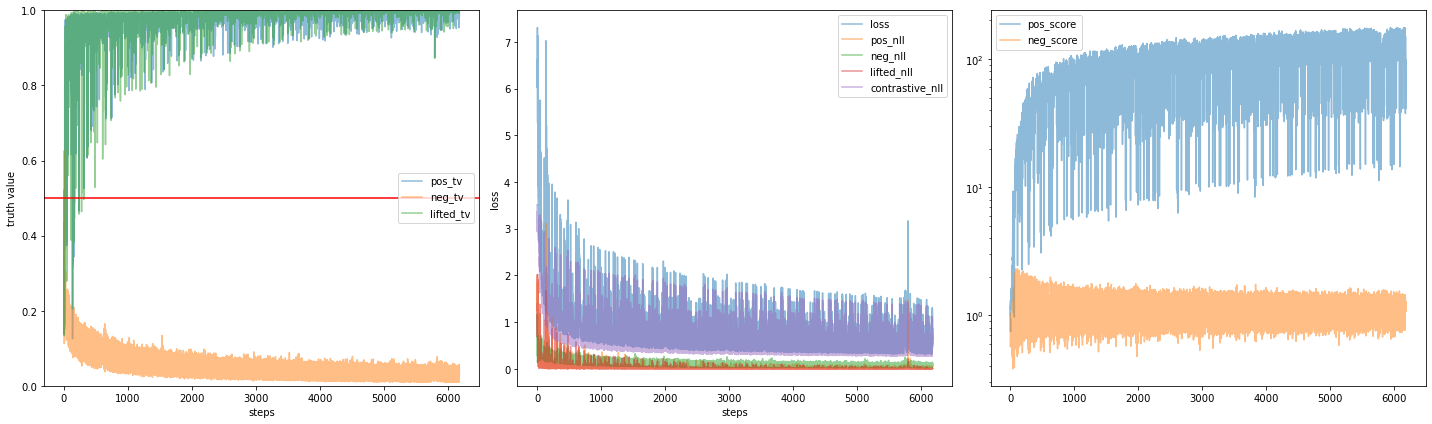

CQD evaluate valid
                1p    2p    3p    2i    3i    ip    pi   2in   3in   inp   pin   pni    2u  2u-dm  up-dm  epfo mean  Neg mean
epoch metric                                                                                                                 
0     mrr    28.16  5.98  5.56  8.98 10.30  5.76  7.93  3.03  3.74  5.57  2.30  2.38  4.70   0.01   0.01      10.38      3.40
1     mrr    23.40  6.37  5.79 10.28 12.49  7.09 10.20  3.50  4.77  5.51  2.68  2.72  4.23   0.01   0.01      10.80      3.83
2     mrr    19.91  5.80  5.54  9.75 11.91  7.45  9.84  3.89  5.61  5.05  2.92  2.81  3.82   0.01   0.01      10.03      4.05
3     mrr    16.65  5.35  5.03  9.75 12.04  8.03 10.48  4.11  5.84  4.57  3.10  3.05  3.46   0.01   0.01       9.62      4.13
4     mrr    15.42  5.32  5.10  9.39 11.76  7.70 10.29  4.05  6.12  4.37  3.06  3.00  3.22   0.01   0.01       9.28      4.12
5     mrr    14.93  4.33  4.46  9.75 12.37  7.91 10.08  4.07  6.39  3.78  3.25  3.19  3.20   0.01  

In [39]:
show_trajectory('log/debug_gnn_reasoner/output.log', metrics=['mrr'])